In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['savefig.dpi'] = 300


columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

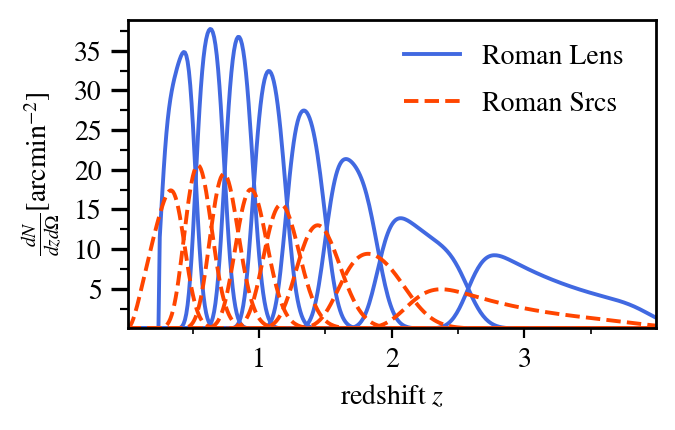

In [7]:
import itertools
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
def make_style_iter():
    #markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    markers = ['o', '^', '*']
    linewidths = [1.2, 1.5]
    linestyles = ['-', '--', '-.', ':']
    return itertools.cycle(itertools.product(markers, linewidths, linestyles))

cmap = plt.get_cmap("cividis")
colors = cmap(np.arange(0, 2)/1)

roman_lens = np.loadtxt('./data/tim_lens_4cosmolike.nz')
roman_srcs =np.loadtxt('./data/fiducial.nz')

def plot_assemble(ax,x,y,label,c,ls,mk='none',lw=1.4):
    (ln, ) = ax.plot(x, y,markersize=6.0,color=c,label=label,linestyle=ls,linewidth=lw,marker=mk,markerfacecolor='none',markevery=10)
    return ln

fig,axs = plt.subplots(1,1,figsize=(columnwidth,2))
plt.subplots_adjust(wspace=0.05)
lines = []
axs.set_ylabel(r'$\frac{dN}{dzd\Omega}[\mathrm{arcmin}^{-2}]$')

lines = []
for i in range(8):
    ln = plot_assemble(axs, roman_lens[:,0], roman_lens[:,i+1]*67.45, label=f'Roman Lens ',c='royalblue', ls='-', mk='none')
lines.append(ln)
for i in range(8):
    ln = plot_assemble(axs, roman_srcs[:,0], roman_srcs[:,i+1]*41, label=f'Roman Srcs ',c='orangered', ls='--', mk='none')
lines.append(ln)
axs.set_xlim(0.01,3.99)
axs.set_ylim(0.1,38.9)
axs.legend(handles=lines, frameon=False)
#axs[0].tick_params(axis='y', which='both', labelleft=False)

axs.yaxis.set_major_locator(MultipleLocator(5))
axs.yaxis.set_minor_locator(MultipleLocator(2.5))
axs.xaxis.set_major_locator(MultipleLocator(1.))
axs.xaxis.set_minor_locator(MultipleLocator(0.5))
axs.set_xlabel(r'redshift $z$', fontsize=10)

plt.savefig('tim_nofz.pdf', dpi=300)